# Bivariate smoothing with coupled latent dynamics

*Author: Stefan T. Radev*

This tutorial introduces time-varying parameter learning with a small bivariate state-space model. The latent target is a two-dimensional parameter trajectory with correlated innovations, and the observations are noisy linear mixtures of the latent state.

The main goal is to distinguish two choices that often get blurred together: filtering versus smoothing, and marginal versus full joint posterior learning. Filtering uses observations only up to the current time; smoothing uses the complete observed sequence (i.e., it's both backward- and forward-looking). Marginal methods learn one time-specific posterior at a time, while joint methods learn a posterior over an entire trajectory and therefore preserve temporal posterior dependence.

With $q$ denoting a learned posterior approximation, the four common targets can be written as:

- Marginal filtering: $q_{\mathrm{MF}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid y_{1:t})$.
- Marginal smoothing: $q_{\mathrm{MS}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid y_{1:T})$.
- Full joint filtering: $q_{\mathrm{JF}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid \theta_{1:t-1}, y_{1:t})$.
- Full joint smoothing: $q_{\mathrm{JS}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid \theta_{1:t-1}, y_{1:T})$.

The marginal products are computationally convienient but they intentionally ignore posterior dependence across time. 

This notebook demos full joint smoothing using bayesflow' `AutoregressiveApproxoimator` that samples complete latent trajectories conditional on observed sequences.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import bayesflow as bf
import keras

np.set_printoptions(suppress=True)

## Generative model

We use a two-dimensional latent random walk with correlated innovations,

$$
\theta_1 \sim \mathcal{N}(0, \sigma_0^2 I),\qquad
\theta_t = \theta_{t-1} + L\eta_t,\qquad
\eta_t \sim \mathcal{N}(0, I_2),
$$

observed through noisy mixed bivariate measurements,

$$
y_t = H\theta_t + \sigma_y\epsilon_t,\qquad
\epsilon_t \sim \mathcal{N}(0, I_2).
$$

The simulator is deliberately simple, but it is not a direct-measurement toy. The Cholesky factor $L$ couples the two latent coordinates through correlated state innovations, so shocks to one parameter dimension tend to move with shocks to the other. The observation matrix $H$ mixes the latent coordinates before noise is added, so each observed channel contains partial information about both latent dimensions.

If we want a more interesting follow-up example, the smallest useful complication would be to let the transition scale, observation scale, or mixing matrix vary across simulated datasets, or to add a weak nonlinear drift. That would create a richer posterior geometry.

The inference target is the complete trajectory $\theta_{1:T}$, and the condition is the complete observed sequence $\{(t, y_t)\}_{1:T}$.

In [ ]:
class StateSpaceSimulator:
    """Two-dimensional random walk observed through a fixed linear mixing matrix."""

    def __init__(self, num_steps=80, initial_sd=0.50, step_sd=0.08, observation_sd=0.30, seed=2027):
        self.num_steps = num_steps
        self.initial_sd = initial_sd
        self.observation_sd = observation_sd
        self.rng = np.random.default_rng(seed)
        self.time = np.linspace(0.0, 1.0, num_steps, dtype="float32")

        self.innovation_cholesky = step_sd * np.array(
            [
                [1.00, 0.00],
                [0.60, 0.80],
            ]
        )
        self.observation_matrix = np.array(
            [
                [1.00, 0.35],
                [-0.25, 0.90],
            ]
        )
        self.unmixing_matrix = np.linalg.inv(self.observation_matrix)

    def sample(self, batch_shape):

        if isinstance(batch_shape, int):
            batch_shape = (batch_shape,)

        batch_shape = tuple(batch_shape)
        batch_size = np.prod(batch_shape)

        initial = self.rng.normal(scale=self.initial_sd, size=(batch_size, 1, 2))
        white_noise = self.rng.normal(size=(batch_size, self.num_steps - 1, 2))
        increments = white_noise @ self.innovation_cholesky.T
        theta = np.concatenate([initial, initial + np.cumsum(increments, axis=1)], axis=1)
        y = theta @ self.observation_matrix.T + self.rng.normal(scale=self.observation_sd, size=theta.shape)

        sequence_shape = batch_shape + (self.num_steps, 2)
        time_shape = batch_shape + (self.num_steps, 1)
        time = np.broadcast_to(self.time[None, :, None], time_shape)

        return {
            "time": time,
            "y": y.reshape(sequence_shape),
            "theta": theta.reshape(sequence_shape),
        }


simulator = StateSpaceSimulator(num_steps=80, seed=2027)
prior_draws = simulator.sample(8)
{k: v.shape for k, v in prior_draws.items()}

{'time': (8, 80, 1), 'y': (8, 80, 2), 'theta': (8, 80, 2)}

## Prior predictive checks

Each panel shows one simulated bivariate trajectory. Solid lines are the latent trajectory. Faint points are the noisy mixed observations projected back onto the latent coordinate system.

Text(0.02, 0.5, 'Parameter value')

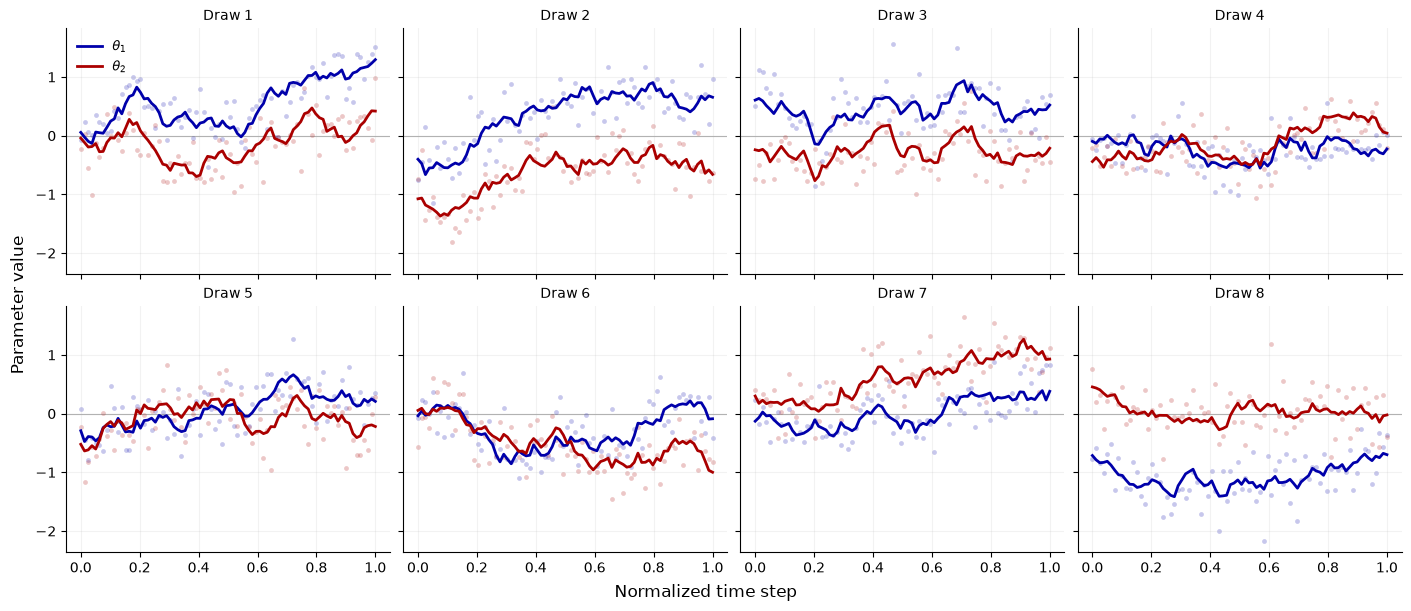

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True, constrained_layout=True)
colors = ["#0000AA", "#AA0000"]

for i, ax in enumerate(axes.flat):
    time = prior_draws["time"][i, :, 0]
    theta = prior_draws["theta"][i]
    y = prior_draws["y"][i]
    unmixed_y = y @ simulator.unmixing_matrix.T

    for dim, color in enumerate(colors):
        ax.scatter(time, unmixed_y[:, dim], color=color, s=12, alpha=0.22, linewidth=0)
        ax.plot(time, theta[:, dim], color=color, linewidth=2, label=fr"$\theta_{dim + 1}$")

    ax.axhline(0.0, color="0.7", linewidth=0.8, zorder=0)
    ax.set_title(f"Draw {i + 1}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.16)

axes.flat[0].legend(frameon=False, fontsize=9)
fig.supxlabel("Normalized time step")
fig.supylabel("Parameter value")

## Adapter and data

The approximator expects two sequence tensors:

- `summary_variables`: what we condition on, here `(t, y_{t,1}, y_{t,2})`.
- `inference_variables`: what we infer, here `(theta_{t,1}, theta_{t,2})`. Note, that the intrinsic dimension of the problem is $\textrm{dim}(\theta_t) = 2$, as the inference network learns to sample one time point at a time.

The rest proceeds like bayesflow as usual.

In [9]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["time", "y", "theta"])
    .concatenate(["time", "y"], into="summary_variables")
    .concatenate(["theta"], into="inference_variables")
)

num_batches = 100
num_val = 256
batch_size = 64

data_val = simulator.sample(num_val)

train_dataset = bf.OnlineDataset(simulator, batch_size=batch_size, num_batches=num_batches, adapter=adapter)
val_dataset = bf.OfflineDataset(data_val, batch_size=batch_size, adapter=adapter, shuffle=False)

adapted_preview = adapter(simulator.sample(2))
adapted_preview["summary_variables"].shape, adapted_preview["inference_variables"].shape

((2, 80, 3), (2, 80, 2))

## Networks

For an `AutoregressiveApproximator`, the sequence model has two parts: an encoder for the observed sequence and a decoder for the target trajectory. Users have four basic building blocks to mix and match:

- Encoder: `bf.networks.RecurrentNetwork(return_sequences=True)` or `bf.networks.TimeSeriesTransformer(return_sequences=True)`.
- Decoder: `bf.networks.RecurrentDecoder()` or `bf.networks.TransformerDecoder()`.

Additionally, any custom encoder/decoder pair is also supported. The important encoder setting is `return_sequences=True`, because the decoder needs one encoded condition per time point rather than a single global summary. Below we demo just one combination: a recurrent encoder and a recurrent decoder. 

The division of labor works like this: 
- The **encoder** reads the complete noisy sequence and returns a sequence of representations of the same length. Each element in this sequence represents a complete summary of the sequence. 
- The **decoder** represents the "memory" of the inference network, as it conditions the bivariate latent trajectory autoregressively, one time point at a time. During inference, it is trained via teacher forcing. During inference, it consumes the past samples of the model at each time step.

In [11]:
# This network will turn the observed sequence into a sequence of hidden states
encoder_network = bf.networks.RecurrentNetwork(
    return_sequences=True,
    time_axis=0,
)

# This network will condition the inference network
decoder_network = bf.networks.RecurrentDecoder()

# This network will sample the trajectory
inference_network = bf.networks.CouplingFlow()

approximator = bf.AutoregressiveApproximator(
    inference_network=inference_network,
    encoder_network=encoder_network,
    decoder_network=decoder_network,
    adapter=adapter,
    standardize="all",
)

## Training

The settings below are small enough for a tutorial notebook. Increase `num_batches` and `epochs` if you want cleaner posterior bands. We use `Adam` since we are in an online (i.e., infinite data) training regime.

In [13]:
epochs = 100

optimizer = keras.optimizers.Adam(
    learning_rate=keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=2e-4,
        decay_steps=epochs * num_batches,
    )
)

approximator.compile(optimizer=optimizer)

Training will take around 5 minutes on a standard GPU. Validation data is not strictly necessary for online training, but it left here as a reminder to include for offline/disk training.

In [ ]:
history = approximator.fit(
    dataset=train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

The loss shows excellent convergence.

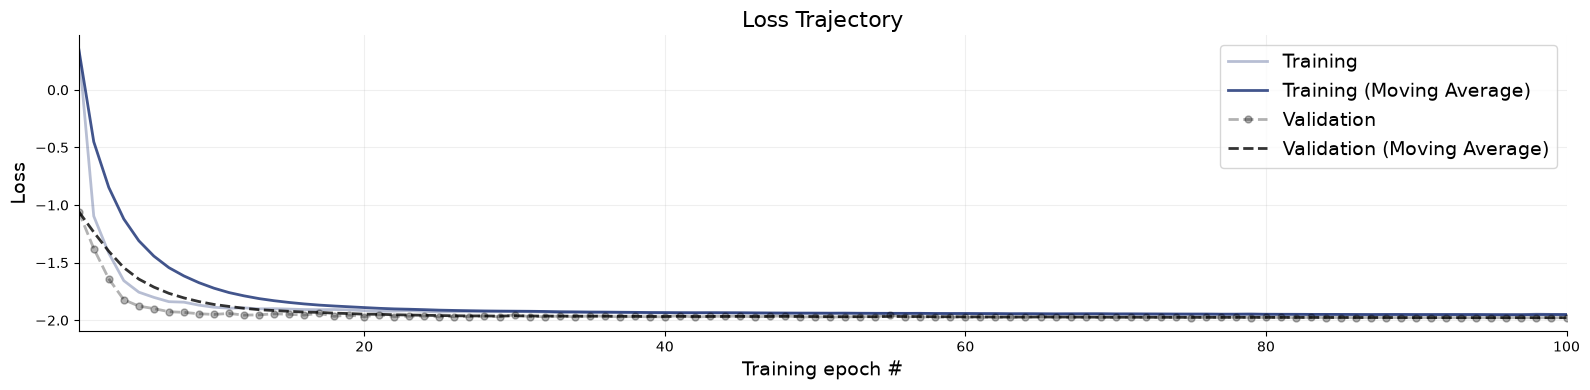

In [15]:
fig = bf.diagnostics.loss(history)

## Posterior smoothing samples

Once training has completed, we can easily sample bivariate trajectories from the learned joint smoother.

In [ ]:
num_test = 5

test_data = simulator.sample(num_test)

posterior = approximator.sample(conditions=test_data, num_samples=1000)

In the plot below, different test datasets are shown in the columns and inferred parameters (latent trajectories) in the rows. The posterior bands are pointwise credible intervals for the parameters per time point. The black line with markers is the ground-truth latent trajectory.

Text(0.02, 0.5, 'Latent value')

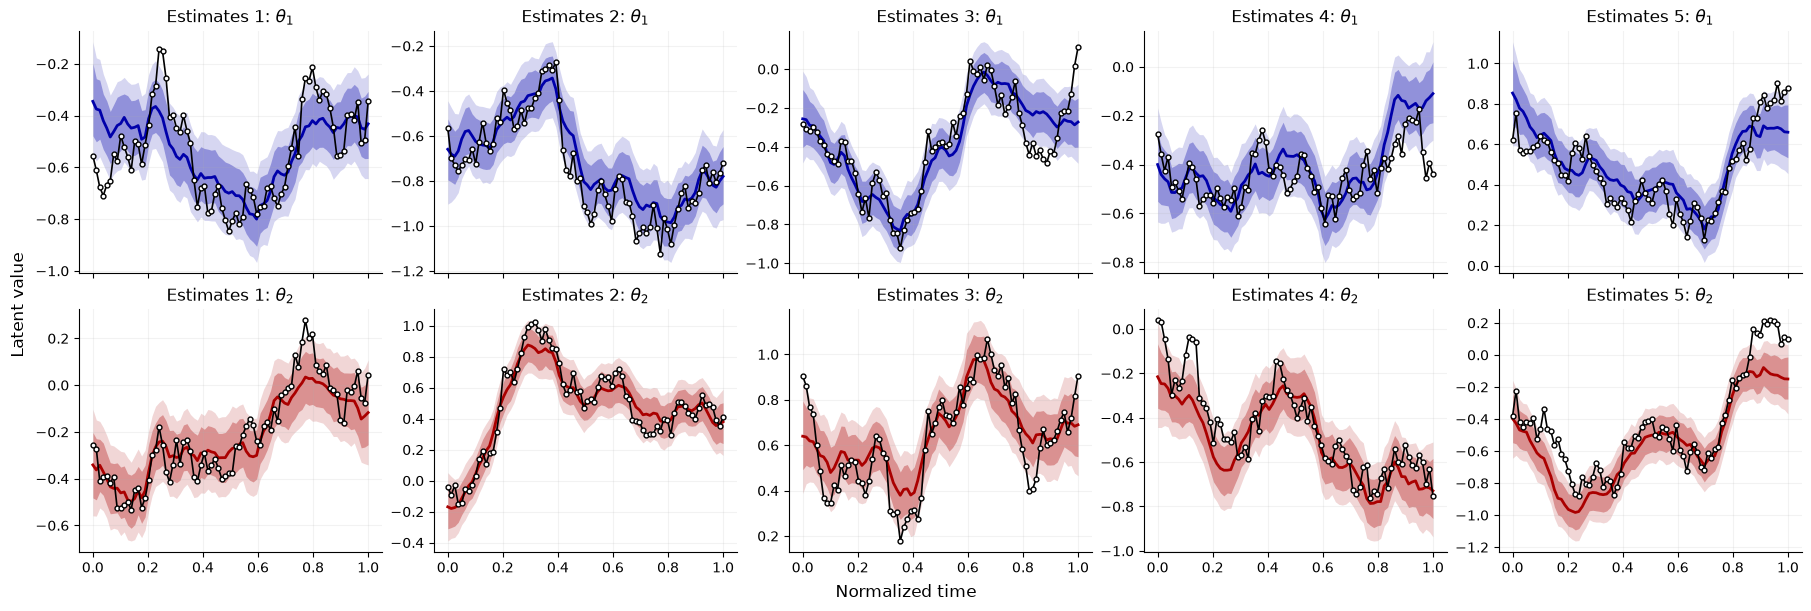

In [19]:
fig, axes = plt.subplots(2, num_test, figsize=(18, 6), sharex=True, constrained_layout=True)
colors = ["#0000AA", "#AA0000"]


def plot_smoother(ax, draws, truth, time, title, color):
    lo89, lo68, med, hi68, hi89 = np.quantile(draws, [0.055, 0.16, 0.5, 0.84, 0.945], axis=0)

    ax.fill_between(time, lo89, hi89, color=color, alpha=0.16, linewidth=0)
    ax.fill_between(time, lo68, hi68, color=color, alpha=0.32, linewidth=0)
    ax.plot(time, med, color=color, linewidth=2)
    ax.plot(
        time,
        truth,
        color="black",
        marker="o",
        markersize=3.5,
        linewidth=1.2,
        markerfacecolor="white",
        markeredgewidth=1,
    )
    ax.set_title(title, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.16)


for i in range(num_test):
    time = test_data["time"][i, :, 0]

    for dim, color in enumerate(colors):
        plot_smoother(
            axes[dim, i],
            posterior["theta"][i, :, :, dim],
            test_data["theta"][i, :, dim],
            time,
            fr"Estimates {i + 1}: $\theta_{dim + 1}$",
            color,
        )


fig.supxlabel("Normalized time")
fig.supylabel("Latent value")

## Next steps

More rigorous diagnostics would be needed to ascertain the fidelity of the autoregressive approximator. These could feature various Bayesian metrics over time, e.g., calibration error, NRMSE, etc. Feel free to

- Switch from online to offline training and explore how performance changes under a much smaller simulation budget.
- Make the generative model more challenging by introducing nonlinear dynamics or non-Gaussian noise.
- Experiment with different encoder and decoder architectures and compare their impact on inference quality.